In [1]:
import pandas as pd

In [29]:
# Load the processed data
print("Loading parquet data...")
df = pd.read_parquet("./tmp/unfv_with_weather_route_29_39.parquet")
print(f"Columns: {df.columns.tolist()}")

Loading parquet data...
Columns: ['route', 'trip_id', 'stopid', 'thrusteet', 'hour', 'day_of_week', 'month', 'day_of_year', 'hour_sin', 'hour_cos', 'day_of_week_sin', 'day_of_week_cos', 'delay_seconds', 'Climate ID', 'Temp (°C)', 'Dew Point Temp (°C)', 'Rel Hum (%)', 'Wind Spd (km/h)', 'Visibility (km)', 'Stn Press (kPa)', 'Precip. Amount (mm)']


In [30]:
df.dtypes

route                         float64
trip_id                string[python]
stopid                 string[python]
thrusteet              string[python]
hour                          float64
day_of_week                   float64
month                         float64
day_of_year                   float64
hour_sin                      float64
hour_cos                      float64
day_of_week_sin               float64
day_of_week_cos               float64
delay_seconds                 float64
Climate ID                    float64
Temp (°C)                     float64
Dew Point Temp (°C)           float64
Rel Hum (%)                   float64
Wind Spd (km/h)               float64
Visibility (km)               float64
Stn Press (kPa)               float64
Precip. Amount (mm)           float64
dtype: object

In [31]:
df_29 = df[df["route"] == 29]

In [32]:
df_29.isna().sum()

route                       0
trip_id                     0
stopid                      0
thrusteet              176437
hour                    40640
day_of_week             40640
month                   40640
day_of_year             40640
hour_sin                40640
hour_cos                40640
day_of_week_sin         40640
day_of_week_cos         40640
delay_seconds           40640
Climate ID                674
Temp (°C)                 674
Dew Point Temp (°C)       674
Rel Hum (%)               674
Wind Spd (km/h)           674
Visibility (km)           674
Stn Press (kPa)           674
Precip. Amount (mm)       674
dtype: int64

In [33]:
df_29[df_29.stopid.str.contains("_")].stopid.value_counts().sum()

np.int64(177373)

In [34]:
def create_bound(stopid):
    if "_" in stopid:
        get_bound = stopid.split("_")[1]
        return int(get_bound)
    else:
        return 0

df_29['bound'] = df_29['stopid'].apply(create_bound)

/tmp/ipykernel_16233/1413578387.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_29['bound'] = df_29['stopid'].apply(create_bound)


In [35]:
df_29[df_29.stopid.str.contains("_")].bound.value_counts().sum()

np.int64(177373)

In [36]:
df_29['stopid'] = df_29['stopid'].apply(lambda x: int(x.split("_")[0]) if "_" in x else int(x))

/tmp/ipykernel_16233/1405639651.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_29['stopid'] = df_29['stopid'].apply(lambda x: int(x.split("_")[0]) if "_" in x else int(x))


In [37]:
df_29.dtypes

route                         float64
trip_id                string[python]
stopid                          int64
thrusteet              string[python]
hour                          float64
day_of_week                   float64
month                         float64
day_of_year                   float64
hour_sin                      float64
hour_cos                      float64
day_of_week_sin               float64
day_of_week_cos               float64
delay_seconds                 float64
Climate ID                    float64
Temp (°C)                     float64
Dew Point Temp (°C)           float64
Rel Hum (%)                   float64
Wind Spd (km/h)               float64
Visibility (km)               float64
Stn Press (kPa)               float64
Precip. Amount (mm)           float64
bound                           int64
dtype: object

In [38]:
df_29.isna().sum()

route                       0
trip_id                     0
stopid                      0
thrusteet              176437
hour                    40640
day_of_week             40640
month                   40640
day_of_year             40640
hour_sin                40640
hour_cos                40640
day_of_week_sin         40640
day_of_week_cos         40640
delay_seconds           40640
Climate ID                674
Temp (°C)                 674
Dew Point Temp (°C)       674
Rel Hum (%)               674
Wind Spd (km/h)           674
Visibility (km)           674
Stn Press (kPa)           674
Precip. Amount (mm)       674
bound                       0
dtype: int64

In [39]:
df_29_no_na = df_29.dropna(subset=['delay_seconds'])

In [40]:
df_29_no_na.isna().sum()

route                       0
trip_id                     0
stopid                      0
thrusteet              173185
hour                        0
day_of_week                 0
month                       0
day_of_year                 0
hour_sin                    0
hour_cos                    0
day_of_week_sin             0
day_of_week_cos             0
delay_seconds               0
Climate ID                674
Temp (°C)                 674
Dew Point Temp (°C)       674
Rel Hum (%)               674
Wind Spd (km/h)           674
Visibility (km)           674
Stn Press (kPa)           674
Precip. Amount (mm)       674
bound                       0
dtype: int64

In [41]:
df_29_no_na_dropped = df_29_no_na.dropna(subset=['Climate ID', 'thrusteet'])

In [42]:
df_29_no_na_dropped.shape

(4851443, 22)

In [43]:
df_29_no_na_filled = df_29_no_na.fillna(0)

In [44]:
df_29_no_na_filled.shape

(5025282, 22)

In [45]:
df_29_no_na_filled.head()

,route,trip_id,stopid,thrusteet,hour,day_of_week,month,day_of_year,hour_sin,hour_cos,...,delay_seconds,Climate ID,Temp (°C),Dew Point Temp (°C),Rel Hum (%),Wind Spd (km/h),Visibility (km),Stn Press (kPa),Precip. Amount (mm),bound
0,29.0,172354080,3880,Wilson Station,0.0,2.0,1.0,1.0,0.0,1.0,...,-40.000,6158731.0,1.6,1.6,100.0,27.0,16.1,97.93,0.5,0
1,29.0,52553080,2728,Princes' Gates Loop,0.0,2.0,1.0,1.0,0.0,1.0,...,-85.971,6158731.0,1.6,1.6,100.0,27.0,16.1,97.93,0.5,1
3,29.0,52553080,3993,Princes' Blvd,0.0,2.0,1.0,1.0,0.0,1.0,...,-5.855,6158731.0,1.6,1.6,100.0,27.0,16.1,97.93,0.5,0
4,29.0,52553080,34800,Princes' Blvd,0.0,2.0,1.0,1.0,0.0,1.0,...,28.000,6158731.0,1.6,1.6,100.0,27.0,16.1,97.93,0.5,0
6,29.0,172354080,1361,Dufferin St,0.0,2.0,1.0,1.0,0.0,1.0,...,29.027,6158731.0,1.6,1.6,100.0,27.0,16.1,97.93,0.5,0


In [46]:
df_29_no_na_filled = pd.get_dummies(df_29_no_na_filled, columns=['thrusteet'], prefix=['thrusteet'], dtype=int)

In [47]:
df_29_no_na_filled.head()

,route,trip_id,stopid,hour,day_of_week,month,day_of_year,hour_sin,hour_cos,day_of_week_sin,...,thrusteet_0,thrusteet_Dufferin St,thrusteet_Manitoba Dr,thrusteet_Nova Scotia Ave,thrusteet_Princes Blvd,thrusteet_Princes' Blvd,thrusteet_Princes' Gates Loop,thrusteet_Saskatchewan Rd,thrusteet_Wilson Ave,thrusteet_Wilson Station
0,29.0,172354080,3880,0.0,2.0,1.0,1.0,0.0,1.0,0.974928,...,0,0,0,0,0,0,0,0,0,1
1,29.0,52553080,2728,0.0,2.0,1.0,1.0,0.0,1.0,0.974928,...,0,0,0,0,0,0,1,0,0,0
3,29.0,52553080,3993,0.0,2.0,1.0,1.0,0.0,1.0,0.974928,...,0,0,0,0,0,1,0,0,0,0
4,29.0,52553080,34800,0.0,2.0,1.0,1.0,0.0,1.0,0.974928,...,0,0,0,0,0,1,0,0,0,0
6,29.0,172354080,1361,0.0,2.0,1.0,1.0,0.0,1.0,0.974928,...,0,1,0,0,0,0,0,0,0,0


In [48]:
df_29_no_na_filled.to_csv("./tmp/unfv_route_29_no_na_filled.csv", index=False)

In [ ]:
df_29_no_na_dropped['thrustreet'] = df_29_no_na_dropped['thrusteet']
df_29_no_na_dropped = pd.get_dummies(df_29_no_na_dropped, columns=['thrusteet'], prefix=['thrusteet'], dtype=int)

/tmp/ipykernel_16233/2988272413.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_29_no_na_dropped['thrustreet'] = df_29_no_na_dropped['thrusteet']


In [ ]:
df_29_no_na_dropped.head(), df_29_no_na_dropped.shape

(   route    trip_id  stopid  hour  day_of_week  month  day_of_year  hour_sin  \
 0   29.0  172354080    3880   0.0          2.0    1.0          1.0       0.0   
 1   29.0   52553080    2728   0.0          2.0    1.0          1.0       0.0   
 3   29.0   52553080    3993   0.0          2.0    1.0          1.0       0.0   
 4   29.0   52553080   34800   0.0          2.0    1.0          1.0       0.0   
 6   29.0  172354080    1361   0.0          2.0    1.0          1.0       0.0   
 
    hour_cos  day_of_week_sin  ...           thrustreet  thrusteet_Dufferin St  \
 0       1.0         0.974928  ...       Wilson Station                      0   
 1       1.0         0.974928  ...  Princes' Gates Loop                      0   
 3       1.0         0.974928  ...        Princes' Blvd                      0   
 4       1.0         0.974928  ...        Princes' Blvd                      0   
 6       1.0         0.974928  ...          Dufferin St                      1   
 
    thrusteet_Mani

In [ ]:
df_29_no_na_dropped.to_csv("./tmp/unfv_route_29_no_na_dropped.csv", index=False)

!Note: Below is not needed

## Detecting Outliers

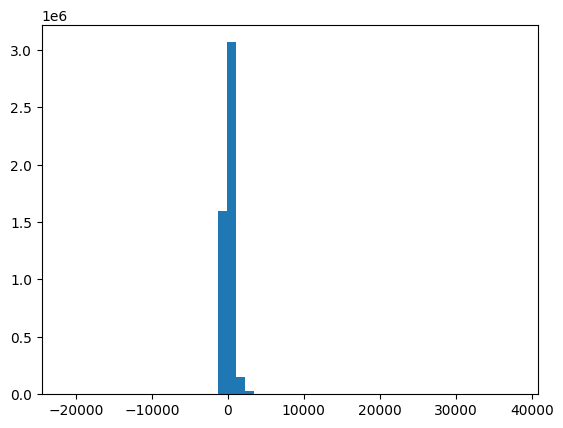

In [25]:
import matplotlib.pyplot as plt
plt.hist(df_29_no_na_dropped['delay_seconds'], bins=50)
plt.show()

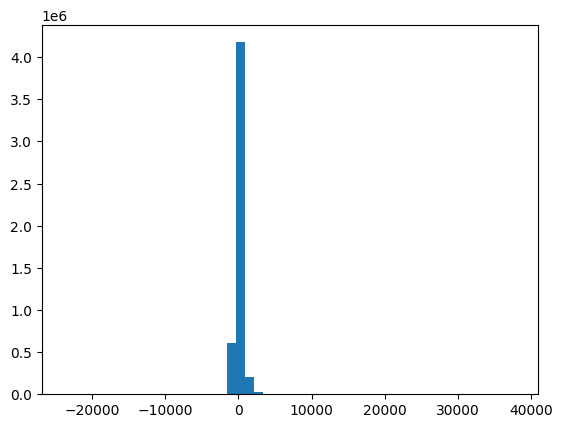

In [26]:
plt.hist(df_29_no_na_filled['delay_seconds'], bins=50)
plt.show()

In [27]:
df_29_no_na_dropped['delay_seconds'].describe()

count    4.851443e+06
mean     3.508565e+01
std      7.771582e+02
min     -2.152100e+04
25%     -2.270000e+02
50%     -5.400000e+01
75%      1.448015e+02
max      3.779996e+04
Name: delay_seconds, dtype: float64

In [28]:
df_29_no_na_filled['delay_seconds'].describe()

count    5.025282e+06
mean     3.352559e+01
std      7.748837e+02
min     -2.375449e+04
25%     -2.300000e+02
50%     -5.431800e+01
75%      1.460000e+02
max      3.779996e+04
Name: delay_seconds, dtype: float64

In [29]:
from sklearn.ensemble import IsolationForest

In [30]:
df_dropped_copy = df_29_no_na_dropped.copy()
df_filled_copy = df_29_no_na_filled.copy()

In [31]:
model=IsolationForest(n_estimators=150, max_samples='auto', contamination="auto", max_features=1.0)
model.fit(df_dropped_copy[['delay_seconds']])

,"n_estimators n_estimators: int, default=100The number of base estimators in the ensemble.",150
,"max_samples max_samples: ""auto"", int or float, default=""auto""The number of samples to draw from X to train each base estimator.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` samples.- If ""auto"", then `max_samples=min(256, n_samples)`.If max_samples is larger than the number of samples provided,all samples will be used for all trees (no sampling).",'auto'
,"contamination contamination: 'auto' or float, default='auto'The amount of contamination of the data set, i.e. the proportionof outliers in the data set. Used when fitting to define the thresholdon the scores of the samples.- If 'auto', the threshold is determined as in the original paper.- If float, the contamination should be in the range (0, 0.5]... versionchanged:: 0.22 The default value of ``contamination`` changed from 0.1 to ``'auto'``.",'auto'
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator.- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.Note: using a float number less than 1.0 or integer less than number offeatures will enable feature subsampling and leads to a longer runtime.",1.0
,"bootstrap bootstrap: bool, default=FalseIf True, individual trees are fit on random subsets of the trainingdata sampled with replacement. If False, sampling without replacementis performed.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for :meth:`fit`. ``None`` means 1unless in a :obj:`joblib.parallel_backend` context. ``-1`` means usingall processors. See :term:`Glossary ` for more details.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo-randomness of the selection of the featureand split values for each branching step and each tree in the forest.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",None
,"verbose verbose: int, default=0Controls the verbosity of the tree building process.",0
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fit a wholenew forest. See :term:`the Glossary `... versionadded:: 0.21",False


In [32]:
scores=model.decision_function(df_dropped_copy[['delay_seconds']])
anomaly=model.predict(df_dropped_copy[['delay_seconds']])

df_dropped_copy['scores']=scores
df_dropped_copy['anomaly']=anomaly

df_dropped_copy.head(10)

,route,trip_id,stopid,hour,day_of_week,month,day_of_year,hour_sin,hour_cos,day_of_week_sin,...,thrusteet_Manitoba Dr,thrusteet_Nova Scotia Ave,thrusteet_Princes Blvd,thrusteet_Princes' Blvd,thrusteet_Princes' Gates Loop,thrusteet_Saskatchewan Rd,thrusteet_Wilson Ave,thrusteet_Wilson Station,scores,anomaly
0,29.0,172354080,3880,0.0,2.0,1.0,1.0,0.0,1.0,0.974928,...,0,0,0,0,0,0,0,1,0.112527,1
1,29.0,52553080,2728,0.0,2.0,1.0,1.0,0.0,1.0,0.974928,...,0,0,0,0,1,0,0,0,0.107173,1
3,29.0,52553080,3993,0.0,2.0,1.0,1.0,0.0,1.0,0.974928,...,0,0,0,1,0,0,0,0,0.110748,1
4,29.0,52553080,34800,0.0,2.0,1.0,1.0,0.0,1.0,0.974928,...,0,0,0,1,0,0,0,0,0.109132,1
6,29.0,172354080,1361,0.0,2.0,1.0,1.0,0.0,1.0,0.974928,...,0,0,0,0,0,0,0,0,0.107789,1
8,29.0,52553080,2815,0.0,2.0,1.0,1.0,0.0,1.0,0.974928,...,0,0,0,0,0,1,0,0,0.109172,1
10,29.0,172354080,9023,0.0,2.0,1.0,1.0,0.0,1.0,0.974928,...,0,0,0,0,0,0,0,0,0.110628,1
13,29.0,52553080,18388,0.0,2.0,1.0,1.0,0.0,1.0,0.974928,...,0,0,0,0,0,0,0,0,0.108689,1
15,29.0,172354080,689,0.0,2.0,1.0,1.0,0.0,1.0,0.974928,...,0,0,0,0,0,0,0,0,0.113483,1
17,29.0,172354080,10406,0.0,2.0,1.0,1.0,0.0,1.0,0.974928,...,0,0,0,0,0,0,0,0,0.113437,1


In [33]:
anomaly = df_dropped_copy.loc[df_dropped_copy['anomaly']==-1]
anomaly_index = list(anomaly.index)
print('Total number of outliers is:', len(anomaly))

Total number of outliers is: 792290


In [34]:
df_dropped_outliers = df_dropped_copy.drop(anomaly_index, axis = 0).reset_index(drop=True)

In [35]:
df_dropped_outliers.shape

(4059153, 31)

In [36]:
df_dropped_outliers.to_csv("./tmp/unfv_route_29_no_na_dropped_outliers_removed.csv", index=False)

In [37]:
model.fit(df_filled_copy[['delay_seconds']])

,"n_estimators n_estimators: int, default=100The number of base estimators in the ensemble.",150
,"max_samples max_samples: ""auto"", int or float, default=""auto""The number of samples to draw from X to train each base estimator.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` samples.- If ""auto"", then `max_samples=min(256, n_samples)`.If max_samples is larger than the number of samples provided,all samples will be used for all trees (no sampling).",'auto'
,"contamination contamination: 'auto' or float, default='auto'The amount of contamination of the data set, i.e. the proportionof outliers in the data set. Used when fitting to define the thresholdon the scores of the samples.- If 'auto', the threshold is determined as in the original paper.- If float, the contamination should be in the range (0, 0.5]... versionchanged:: 0.22 The default value of ``contamination`` changed from 0.1 to ``'auto'``.",'auto'
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator.- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.Note: using a float number less than 1.0 or integer less than number offeatures will enable feature subsampling and leads to a longer runtime.",1.0
,"bootstrap bootstrap: bool, default=FalseIf True, individual trees are fit on random subsets of the trainingdata sampled with replacement. If False, sampling without replacementis performed.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for :meth:`fit`. ``None`` means 1unless in a :obj:`joblib.parallel_backend` context. ``-1`` means usingall processors. See :term:`Glossary ` for more details.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo-randomness of the selection of the featureand split values for each branching step and each tree in the forest.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",None
,"verbose verbose: int, default=0Controls the verbosity of the tree building process.",0
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fit a wholenew forest. See :term:`the Glossary `... versionadded:: 0.21",False


In [38]:
scores=model.decision_function(df_filled_copy[['delay_seconds']])
anomaly=model.predict(df_filled_copy[['delay_seconds']])

df_filled_copy['scores']=scores
df_filled_copy['anomaly']=anomaly

df_filled_copy.head(10)

,route,trip_id,stopid,hour,day_of_week,month,day_of_year,hour_sin,hour_cos,day_of_week_sin,...,thrusteet_Manitoba Dr,thrusteet_Nova Scotia Ave,thrusteet_Princes Blvd,thrusteet_Princes' Blvd,thrusteet_Princes' Gates Loop,thrusteet_Saskatchewan Rd,thrusteet_Wilson Ave,thrusteet_Wilson Station,scores,anomaly
0,29.0,172354080,3880,0.0,2.0,1.0,1.0,0.0,1.0,0.974928,...,0,0,0,0,0,0,0,1,0.092542,1
1,29.0,52553080,2728,0.0,2.0,1.0,1.0,0.0,1.0,0.974928,...,0,0,0,0,1,0,0,0,0.092988,1
3,29.0,52553080,3993,0.0,2.0,1.0,1.0,0.0,1.0,0.974928,...,0,0,0,1,0,0,0,0,0.095326,1
4,29.0,52553080,34800,0.0,2.0,1.0,1.0,0.0,1.0,0.974928,...,0,0,0,1,0,0,0,0,0.089537,1
6,29.0,172354080,1361,0.0,2.0,1.0,1.0,0.0,1.0,0.974928,...,0,0,0,0,0,0,0,0,0.089172,1
8,29.0,52553080,2815,0.0,2.0,1.0,1.0,0.0,1.0,0.974928,...,0,0,0,0,0,1,0,0,0.093759,1
10,29.0,172354080,9023,0.0,2.0,1.0,1.0,0.0,1.0,0.974928,...,0,0,0,0,0,0,0,0,0.095901,1
13,29.0,52553080,18388,0.0,2.0,1.0,1.0,0.0,1.0,0.974928,...,0,0,0,0,0,0,0,0,0.092078,1
15,29.0,172354080,689,0.0,2.0,1.0,1.0,0.0,1.0,0.974928,...,0,0,0,0,0,0,0,0,0.095839,1
17,29.0,172354080,10406,0.0,2.0,1.0,1.0,0.0,1.0,0.974928,...,0,0,0,0,0,0,0,0,0.092407,1


In [39]:
anomaly = df_filled_copy.loc[df_filled_copy['anomaly']==-1]
anomaly_index = list(anomaly.index)
print('Total number of outliers is:', len(anomaly))

Total number of outliers is: 800247


In [40]:
df_filled_outliers = df_filled_copy.drop(anomaly_index, axis = 0).reset_index(drop=True)

In [41]:
df_filled_outliers.shape

(4225035, 32)

In [42]:
df_filled_outliers.to_csv("./tmp/unfv_route_29_no_na_filled_outliers_removed.csv", index=False)